In [ ]:
# Prometheus logs analysis

In [2]:
import requests
import os

# 1. Define your list of nodes
# Add any other node names here (e.g. 'alice', 'bob', 'charlie')
RELAYS = ["ferdie", "george", "henry", "iris", "jack", "paul", "quinn", "rita", "sam", "tom"]
BLOCK_PRODUCERS = ["alice", "bob", "charlie", "dave", "eve", "kate", "leo", "mike", "nina", "oliver"]
NODES = RELAYS + BLOCK_PRODUCERS

# 2. Define the pattern
base_url = "http://{name}.node.sc.iog.io:9615/metrics"

print(f"Starting download for {len(NODES)} nodes...\n")

for node in NODES:
    # Construct the specific URL and Filename
    url = base_url.format(name=node)
    filename = f"prometheus_{node}.log"
    
    try:
        print(f"📡 Fetching {node}...", end=" ")
        
        # Perform the request (timeout ensures it doesn't hang forever)
        response = requests.get(url, timeout=10)
        response.raise_for_status() # Raises error if 404/500
        
        # Save to file
        with open(filename, "w", encoding="utf-8") as f:
            f.write(response.text)
            
        print(f"✅ Saved to {filename}")
        
    except requests.exceptions.RequestException as e:
        print(f"❌ Failed: {e}")

print("\nAll done.")

Starting download for 20 nodes...

📡 Fetching ferdie... ✅ Saved to prometheus_ferdie.log
📡 Fetching george... ✅ Saved to prometheus_george.log
📡 Fetching henry... ✅ Saved to prometheus_henry.log
📡 Fetching iris... ✅ Saved to prometheus_iris.log
📡 Fetching jack... ✅ Saved to prometheus_jack.log
📡 Fetching paul... ✅ Saved to prometheus_paul.log
📡 Fetching quinn... ✅ Saved to prometheus_quinn.log
📡 Fetching rita... ✅ Saved to prometheus_rita.log
📡 Fetching sam... ✅ Saved to prometheus_sam.log
📡 Fetching tom... ✅ Saved to prometheus_tom.log
📡 Fetching alice... ✅ Saved to prometheus_alice.log
📡 Fetching bob... ✅ Saved to prometheus_bob.log
📡 Fetching charlie... ✅ Saved to prometheus_charlie.log
📡 Fetching dave... ✅ Saved to prometheus_dave.log
📡 Fetching eve... ✅ Saved to prometheus_eve.log
📡 Fetching kate... ✅ Saved to prometheus_kate.log
📡 Fetching leo... ✅ Saved to prometheus_leo.log
📡 Fetching mike... ✅ Saved to prometheus_mike.log
📡 Fetching nina... ✅ Saved to prometheus_nina.log
📡 Fet

Scanning '.' for *.log files...
aggregated metrics from 20 log files.


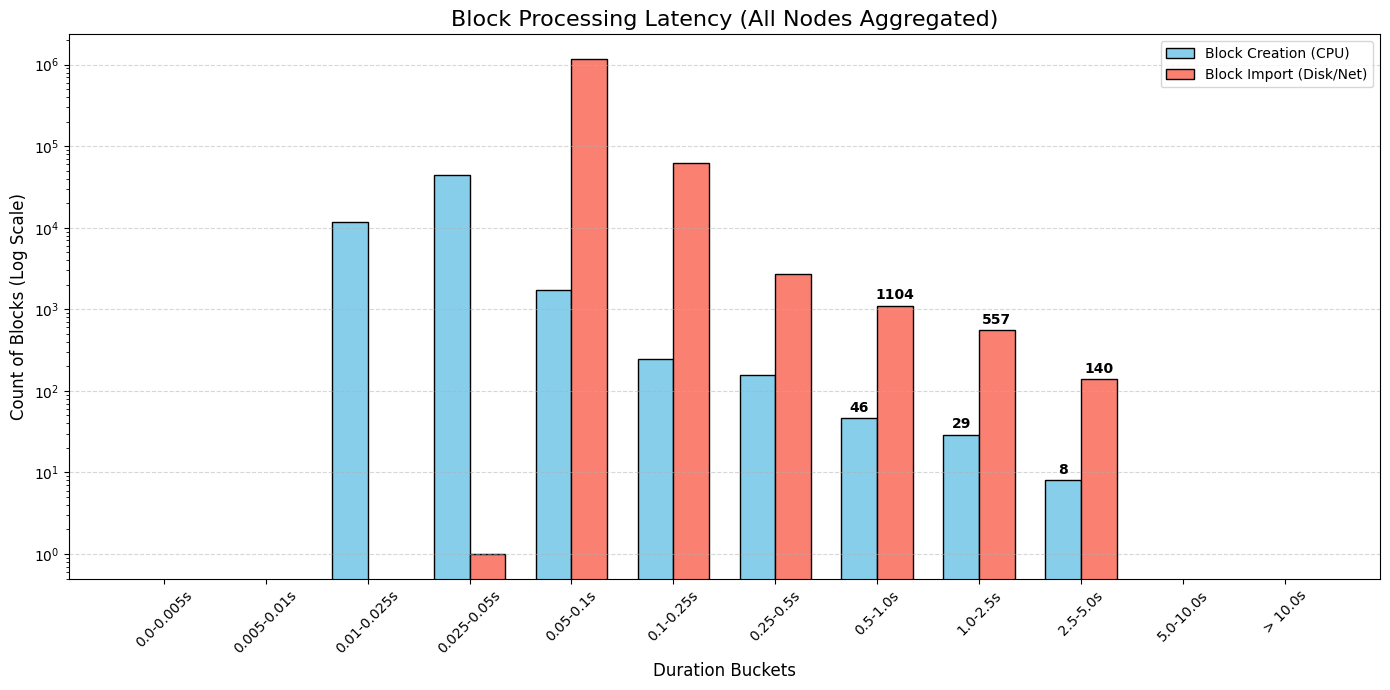


--- Outlier Detail (Slowest Blocks) ---
       Interval  Proposal_Count  Import_Count
0    0.0-0.005s               0             0
1   0.005-0.01s               0             0
2   0.01-0.025s           11651             0
3   0.025-0.05s           44828             1
4     0.05-0.1s            1749       1171890
5     0.1-0.25s             246         62368
6     0.25-0.5s             157          2743
7      0.5-1.0s              46          1104
8      1.0-2.5s              29           557
9      2.5-5.0s               8           140
10    5.0-10.0s               0             0
11      > 10.0s               0             0


In [3]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
# We set this to "." to scan the current folder where you just saved the files
LOG_FOLDER = "."  
FILE_EXTENSION = ".log" 

# Metric names to hunt for
METRIC_PROP = "substrate_proposer_block_proposal_time"
METRIC_IMPORT = "substrate_block_verification_and_import_time"

# ==========================================
# PARSER LOGIC
# ==========================================
def parse_prometheus_buckets(file_content, metric_name):
    """
    Extracts bucket counts for a specific metric from raw Prometheus text.
    """
    # Regex to capture: metric_bucket{... le="0.005"} 123
    pattern = re.compile(rf'{metric_name}_bucket\{{.*le="([\d\.\+Inf]+)".*\}} (\d+)')
    
    bucket_map = {}
    
    for line in file_content.splitlines():
        if metric_name + "_bucket" not in line:
            continue
            
        match = pattern.search(line)
        if match:
            le_str = match.group(1)
            # Handle standard Prometheus "+Inf"
            if "+Inf" in le_str:
                le_val = float('inf')
            else:
                try:
                    le_val = float(le_str)
                except ValueError:
                    continue
            
            count = int(float(match.group(2)))
            
            # Use max count found (cumulative counter logic)
            if le_val in bucket_map:
                bucket_map[le_val] = max(bucket_map[le_val], count)
            else:
                bucket_map[le_val] = count
                
    return bucket_map

def aggregate_logs(folder, extension):
    total_prop_buckets = {}
    total_import_buckets = {}
    files_found = 0
    
    print(f"Scanning '{folder}' for *{extension} files...")
    
    for filename in os.listdir(folder):
        if filename.endswith(extension) and filename.startswith("prometheus_"):
            files_found += 1
            path = os.path.join(folder, filename)
            
            try:
                with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                    
                # Parse file
                prop_data = parse_prometheus_buckets(content, METRIC_PROP)
                import_data = parse_prometheus_buckets(content, METRIC_IMPORT)
                
                # Merge into totals
                for le, count in prop_data.items():
                    total_prop_buckets[le] = total_prop_buckets.get(le, 0) + count
                    
                for le, count in import_data.items():
                    total_import_buckets[le] = total_import_buckets.get(le, 0) + count
                    
            except Exception as e:
                print(f"Error reading {filename}: {e}")
                
    print(f"aggregated metrics from {files_found} log files.")
    return total_prop_buckets, total_import_buckets

def buckets_to_intervals(bucket_map):
    if not bucket_map:
        return [], []
    
    sorted_buckets = sorted(bucket_map.items(), key=lambda x: x[0])
    
    intervals = []
    counts = []
    prev_count = 0
    prev_le = 0.0
    
    for le_val, total_count in sorted_buckets:
        current_interval_count = total_count - prev_count
        if current_interval_count < 0: current_interval_count = 0 
        
        if le_val == float('inf'):
            label = f"> {prev_le}s"
        else:
            label = f"{prev_le}-{le_val}s"
            
        intervals.append(label)
        counts.append(current_interval_count)
        
        prev_count = total_count
        prev_le = le_val
        
    return intervals, counts

# ==========================================
# MAIN EXECUTION
# ==========================================

# 1. Aggregate Data
prop_buckets, import_buckets = aggregate_logs(LOG_FOLDER, FILE_EXTENSION)

# 2. Process into Intervals
p_intervals, p_counts = buckets_to_intervals(prop_buckets)
i_intervals, i_counts = buckets_to_intervals(import_buckets)

# 3. Create DataFrame
df_prop = pd.DataFrame({'Interval': p_intervals, 'Proposal_Count': p_counts})
df_import = pd.DataFrame({'Interval': i_intervals, 'Import_Count': i_counts})

if df_prop.empty and df_import.empty:
    print("⚠️ No Prometheus data found. Did the download script run successfully?")
else:
    # Merge on Interval
    df = pd.merge(df_prop, df_import, on='Interval', how='outer').fillna(0)

    # Sort helper
    def extract_upper(x):
        if ">" in x: return float('inf')
        try: return float(x.split('-')[1].replace('s',''))
        except: return 0

    df['sort'] = df['Interval'].apply(extract_upper)
    df = df.sort_values('sort').drop('sort', axis=1)

    # 4. Plot
    plt.figure(figsize=(14, 7))
    bar_width = 0.35
    index = np.arange(len(df))

    # Log scale is crucial for viewing outliers
    plt.yscale('log')

    # Bars
    p_bars = plt.bar(index, df['Proposal_Count'], bar_width, label='Block Creation (CPU)', color='skyblue', edgecolor='black')
    i_bars = plt.bar(index + bar_width, df['Import_Count'], bar_width, label='Block Import (Disk/Net)', color='salmon', edgecolor='black')

    # Styling
    plt.xlabel('Duration Buckets', fontsize=12)
    plt.ylabel('Count of Blocks (Log Scale)', fontsize=12)
    plt.title('Block Processing Latency (All Nodes Aggregated)', fontsize=16)
    plt.xticks(index + bar_width / 2, df['Interval'], rotation=45)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Annotate significant outliers (only show numbers for buckets > 0.5s)
    def annotate_bars(bars, data_col):
        for i, rect in enumerate(bars):
            height = rect.get_height()
            label = df.iloc[i]['Interval']
            
            # Show number if count > 0 AND it's a slow bucket
            is_slow = any(x in label for x in ["0.5-", "1.0-", "2.5-", "5.0-", ">"])
            
            if height > 0 and is_slow:
                plt.text(rect.get_x() + rect.get_width()/2., height * 1.1,
                        f'{int(height)}',
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    annotate_bars(p_bars, 'Proposal_Count')
    annotate_bars(i_bars, 'Import_Count')

    plt.tight_layout()
    plt.show()

    # Optional: Print the raw table for the tail
    print("\n--- Outlier Detail (Slowest Blocks) ---")
    print(df[df['Interval'].str.contains("0.5|1.0|2.5|5.0|>")])

Scanning '.' for *.log files...
Aggregated metrics from 20 log files.


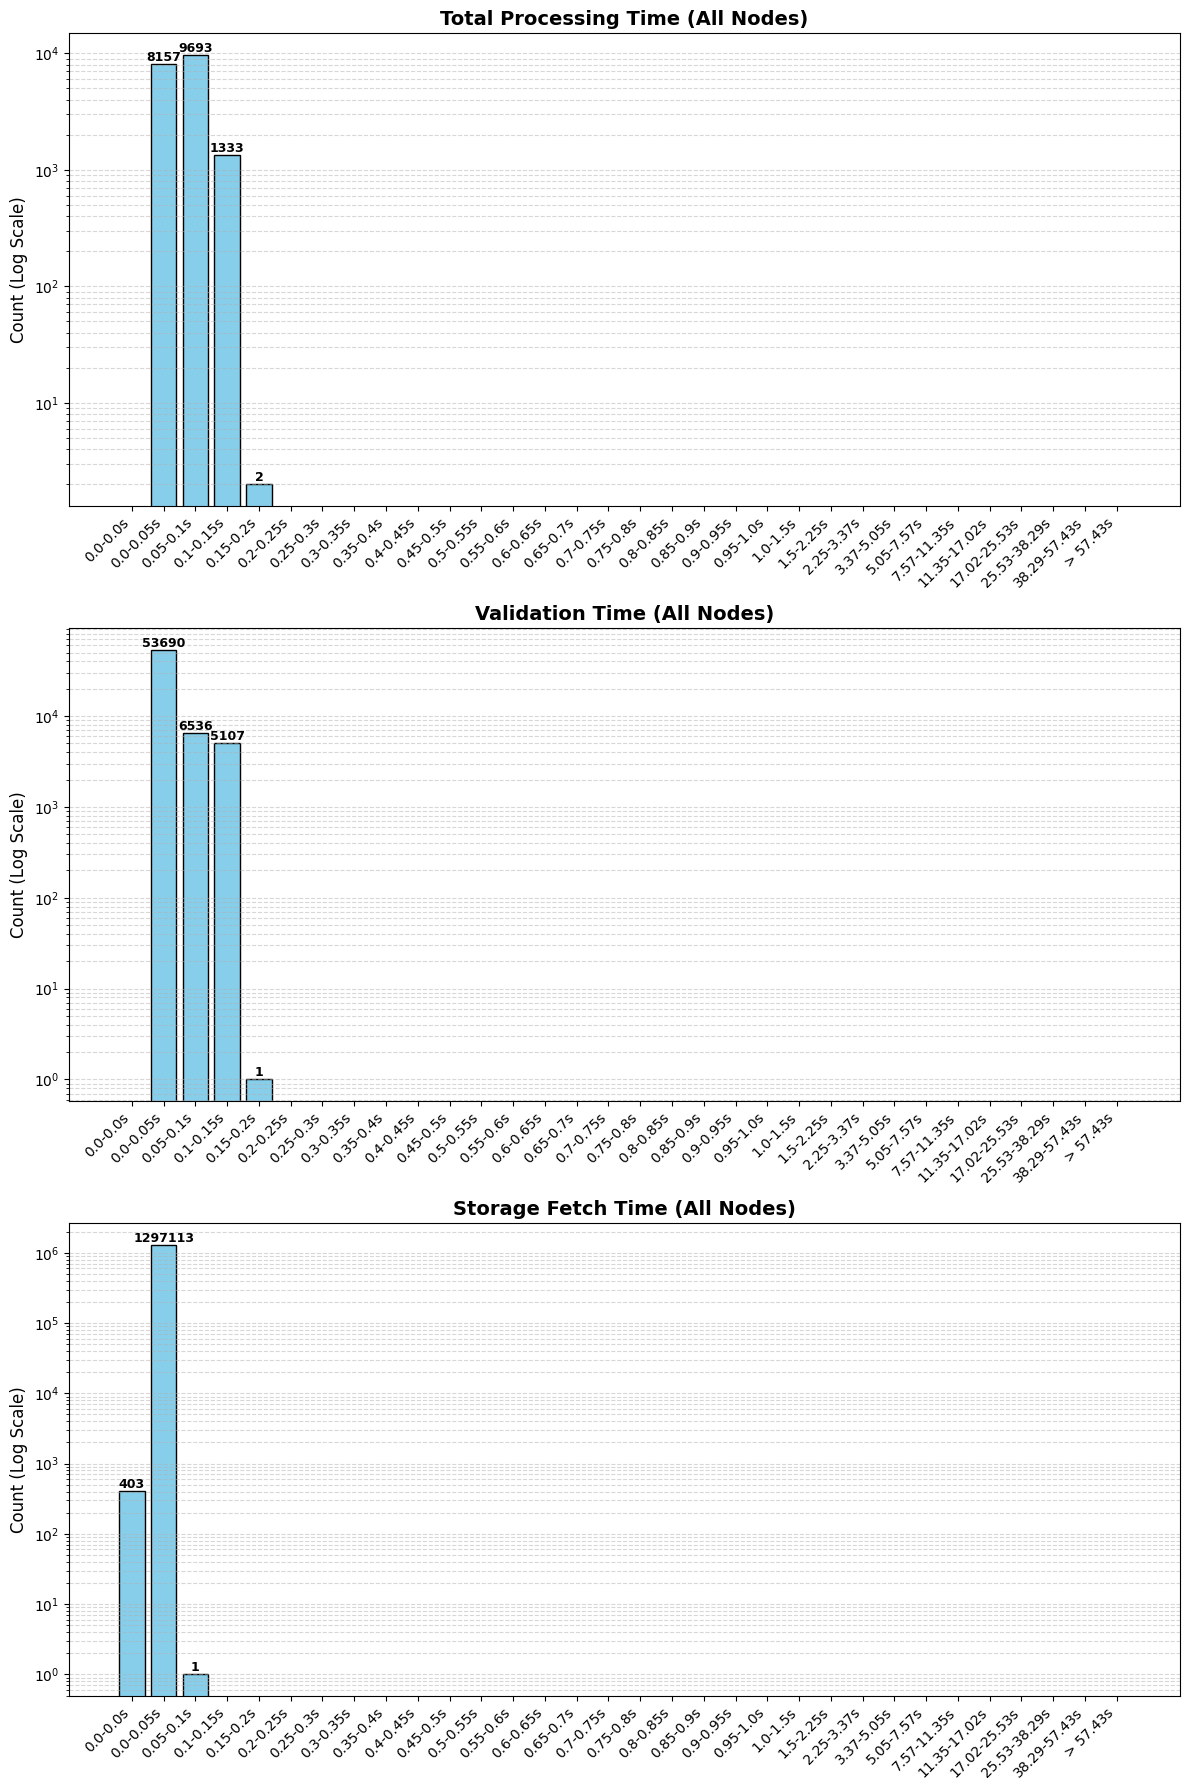

In [5]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
# Set to "." to scan the current folder, or provide a specific path
LOG_FOLDER = "."  
FILE_EXTENSION = ".log" 

# List of metrics to analyze (Metric Name, Display Title)
METRICS_CONFIG = [
    ("ledger_txs_processing_time", "Total Processing Time"),
    ("ledger_txs_validating_time", "Validation Time"),
    ("storage_fetch_time", "Storage Fetch Time")
]

# ==========================================
# PARSER LOGIC
# ==========================================
def parse_prometheus_buckets(file_content, metric_name):
    """
    Extracts bucket counts for a specific metric from raw Prometheus text.
    Returns a dict: {le_value: count}
    """
    # Regex to capture: metric_bucket{... le="0.005"} 123
    pattern = re.compile(rf'{metric_name}_bucket\{{.*le="([\d\.\+Inf]+)".*\}} (\d+)')
    
    bucket_map = {}
    
    for line in file_content.splitlines():
        if metric_name + "_bucket" not in line:
            continue
            
        match = pattern.search(line)
        if match:
            le_str = match.group(1)
            # Handle standard Prometheus "+Inf"
            if "+Inf" in le_str:
                le_val = float('inf')
            else:
                try:
                    le_val = float(le_str)
                except ValueError:
                    continue
            
            count = int(float(match.group(2)))
            
            # Use max count found in this specific file (cumulative counter logic)
            if le_val in bucket_map:
                bucket_map[le_val] = max(bucket_map[le_val], count)
            else:
                bucket_map[le_val] = count
                
    return bucket_map

def aggregate_logs(folder, extension, metrics_list):
    """
    Scans folder for files and aggregates buckets for all requested metrics.
    Returns a dict: {metric_name: {le_value: total_count}}
    """
    aggregated_data = {m_name: {} for m_name, _ in metrics_list}
    files_found = 0
    
    print(f"Scanning '{folder}' for *{extension} files...")
    
    for filename in os.listdir(folder):
        if filename.endswith(extension) and "prometheus" in filename:
            files_found += 1
            path = os.path.join(folder, filename)
            
            try:
                with open(path, 'r', encoding='utf-8', errors='ignore') as f:
                    content = f.read()
                
                for metric_name, _ in metrics_list:
                    file_buckets = parse_prometheus_buckets(content, metric_name)
                    for le, count in file_buckets.items():
                        current_total = aggregated_data[metric_name].get(le, 0)
                        aggregated_data[metric_name][le] = current_total + count
                        
            except Exception as e:
                print(f"Error reading {filename}: {e}")
                
    print(f"Aggregated metrics from {files_found} log files.")
    return aggregated_data

def buckets_to_intervals(bucket_map):
    """
    Converts cumulative buckets (le) into non-cumulative interval counts.
    """
    if not bucket_map:
        return [], []
    
    sorted_buckets = sorted(bucket_map.items(), key=lambda x: x[0])
    
    intervals = []
    counts = []
    prev_count = 0
    prev_le = 0.0
    
    for le_val, total_count in sorted_buckets:
        current_interval_count = total_count - prev_count
        if current_interval_count < 0: current_interval_count = 0 
        
        if le_val == float('inf'):
            label = f"> {prev_le}s"
        else:
            label = f"{prev_le}-{le_val}s"
            
        intervals.append(label)
        counts.append(current_interval_count)
        
        prev_count = total_count
        prev_le = le_val
        
    return intervals, counts

# ==========================================
# MAIN EXECUTION
# ==========================================

# 1. Aggregate Data
aggregated_results = aggregate_logs(LOG_FOLDER, FILE_EXTENSION, METRICS_CONFIG)

# 2. Setup Plotting
num_metrics = len(METRICS_CONFIG)
fig, axes = plt.subplots(num_metrics, 1, figsize=(12, 6 * num_metrics)) # Increased height slightly
plt.subplots_adjust(hspace=0.5)

if num_metrics == 1:
    axes = [axes]

for idx, (metric_name, title) in enumerate(METRICS_CONFIG):
    ax = axes[idx]
    
    buckets = aggregated_results.get(metric_name, {})
    intervals, counts = buckets_to_intervals(buckets)
    
    if not intervals:
        ax.text(0.5, 0.5, f"No data found for {metric_name}", ha='center', va='center')
        ax.set_title(title)
        continue

    df = pd.DataFrame({'Interval': intervals, 'Count': counts})
    
    # Sort numerically
    def extract_upper(x):
        if ">" in x: return float('inf')
        try: return float(x.split('-')[1].replace('s',''))
        except: return 0

    df['sort'] = df['Interval'].apply(extract_upper)
    df = df.sort_values('sort').drop('sort', axis=1)
    
    # OPTIONAL: If you have too many buckets, uncomment the line below to trim
    # df = df.head(25) 

    # Plot Bar Chart
    index = np.arange(len(df))
    bars = ax.bar(index, df['Count'], color='skyblue', edgecolor='black')
    
    # --- LOG SCALE CONFIGURATION ---
    ax.set_yscale('log')
    
    ax.set_title(f"{title} (All Nodes)", fontsize=14, fontweight='bold')
    ax.set_ylabel('Count (Log Scale)', fontsize=12)
    ax.set_xticks(index)
    ax.set_xticklabels(df['Interval'], rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.5, which='both') # Grid for log scale

    # Annotate bars
    for i, rect in enumerate(bars):
        height = rect.get_height()
        if height > 0:
            # Adjust label position slightly for log scale visibility
            ax.text(rect.get_x() + rect.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()